
--- Curva di luce per SZ_Lyn ---

--- Curva di luce per bjr_415 ---

--- Curva di luce per bjr_416 ---


/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:60: RuntimeWarning: invalid value encountered in log10
  return 10.481 + 2.5 * np.log10(fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:62: RuntimeWarning: invalid value encountered in log10
  return 11.222 + 2.5 * np.log10(fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:64: RuntimeWarning: invalid value encountered in log10
  bjr_415_conv = 10.481 + 2.5 * np.log10(bjr_415_fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:65: RuntimeWarning: invalid value encountered in log10
  bjr_416_conv = 11.222 + 2.5 * np.log10(bjr_416_fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:67: RuntimeWarning: invalid value encountered in log10
  return conv_mean - 2.5 * np.log10(fluxes)


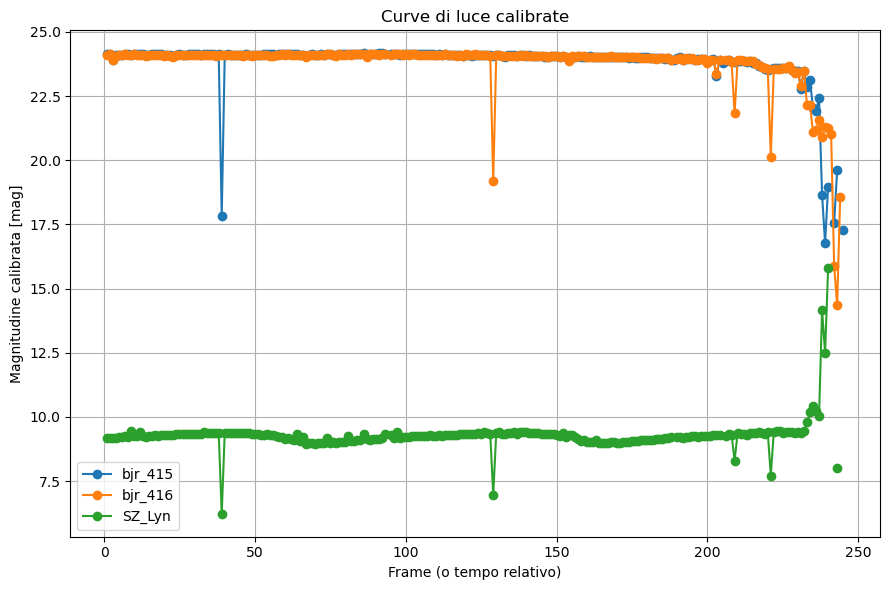

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import re

def load_reduced_image(filepath):
    with fits.open(filepath) as hdul:
        return hdul[0].data.astype(np.float64)

def extract_subimage(image, x_range, y_range):
    return image[y_range[0]:y_range[1], x_range[0]:x_range[1]]

def create_circular_mask(shape, center, radius):
    rows, cols = np.ogrid[:shape[0], :shape[1]]
    y, x = center
    mask = (rows - y)**2 + (cols - x)**2 <= radius**2
    return mask

def aperture_photometry(subimage, radius, gain=0.82, read_noise=10):
    pos_max = np.unravel_index(np.nanargmax(subimage), subimage.shape)
    mask = create_circular_mask(subimage.shape, pos_max, radius)

    target = np.copy(subimage)
    bckg = np.copy(subimage)
    target[~mask] = np.nan
    bckg[mask] = np.nan

    target_flux = target * gain
    bckg_flux = bckg * gain
    object_flux = target_flux - np.nanmean(bckg_flux)

    return np.nansum(object_flux)
#-------------------------------------------------------------------------------------

def light_curve_from_series(directory, prefix, suffix='_reduced.fit',
                            x_range=(550, 670), y_range=(800, 920), radius=15):
    fluxes = []
    frames = []

    files = sorted([f for f in os.listdir(directory) if f.startswith(prefix) and f.endswith(suffix)],
                   key=lambda x: int(re.findall(r'\d+', x)[0]))

    for i, fname in enumerate(files):
        path = os.path.join(directory, fname)
        image = load_reduced_image(path)
        subimage = extract_subimage(image, x_range, y_range)
        flux = aperture_photometry(subimage, radius)

        fluxes.append(flux)
        frames.append(i + 1)

        #print(f"{fname} -> Flusso: {flux:.2f}")

    return frames, fluxes

# Calibrazione dei flussi
def calibrate_fluxes(fluxes, star_name, bjr_415_fluxes=None, bjr_416_fluxes=None):
    if star_name == 'bjr_415':
        return 10.481 + 2.5 * np.log10(fluxes)
    elif star_name == 'bjr_416':
        return 11.222 + 2.5 * np.log10(fluxes)
    elif star_name == 'SZ_Lyn' and bjr_415_fluxes is not None and bjr_416_fluxes is not None:
        bjr_415_conv = 10.481 + 2.5 * np.log10(bjr_415_fluxes)
        bjr_416_conv = 11.222 + 2.5 * np.log10(bjr_416_fluxes)
        conv_mean = np.mean([bjr_415_conv, bjr_416_conv], axis=0)
        return conv_mean - 2.5 * np.log10(fluxes)
    else:
        return fluxes

# Funzione per calcolare e plottare le curve di luce calibrate
def plot_calibrated_light_curves(directory, prefix, suffix, star_regions, radius=15):
    results = {}
    raw_fluxes = {}

    for star_name, (x_range, y_range) in star_regions.items():
        print(f"\n--- Curva di luce per {star_name} ---")
        frames, fluxes = light_curve_from_series(directory, prefix, suffix,
                                                 x_range=x_range, y_range=y_range, radius=radius)
        raw_fluxes[star_name] = np.array(fluxes)

    # Calibrazione
    results['bjr_415'] = (frames, calibrate_fluxes(raw_fluxes['bjr_415'], 'bjr_415'))
    results['bjr_416'] = (frames, calibrate_fluxes(raw_fluxes['bjr_416'], 'bjr_416'))
    results['SZ_Lyn'] = (frames, calibrate_fluxes(raw_fluxes['SZ_Lyn'], 'SZ_Lyn',
                                                  bjr_415_fluxes=raw_fluxes['bjr_415'],
                                                  bjr_416_fluxes=raw_fluxes['bjr_416']))

    # Plotting
    plt.figure(figsize=(9, 6))
    for star_name, (frames, calibrated_fluxes) in results.items():
        plt.plot(frames, calibrated_fluxes, marker='o', linestyle='-', label=star_name)

    plt.xlabel("Frame (o tempo relativo)")
    #plt.xlim(0,100)
    plt.ylabel("Magnitudine calibrata [mag]")
    plt.title("Curve di luce calibrate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Esecuzione della funzione con la calibrazione
if __name__ == "__main__":
    base_dir = '/Users/claudiamurro/Desktop/laboratorio tecnologie astronomiche/cupani/reduced'
    file_prefix = 'SZ_Lyn-'

    star_regions = {
        'SZ_Lyn':  ((550, 670), (800, 920)),
        'bjr_415': ((790, 910), (630, 750)),   
        'bjr_416': ((480, 600), (550, 670))  
    }

    plot_calibrated_light_curves(base_dir, file_prefix, '_reduced.fit', star_regions, radius=15)

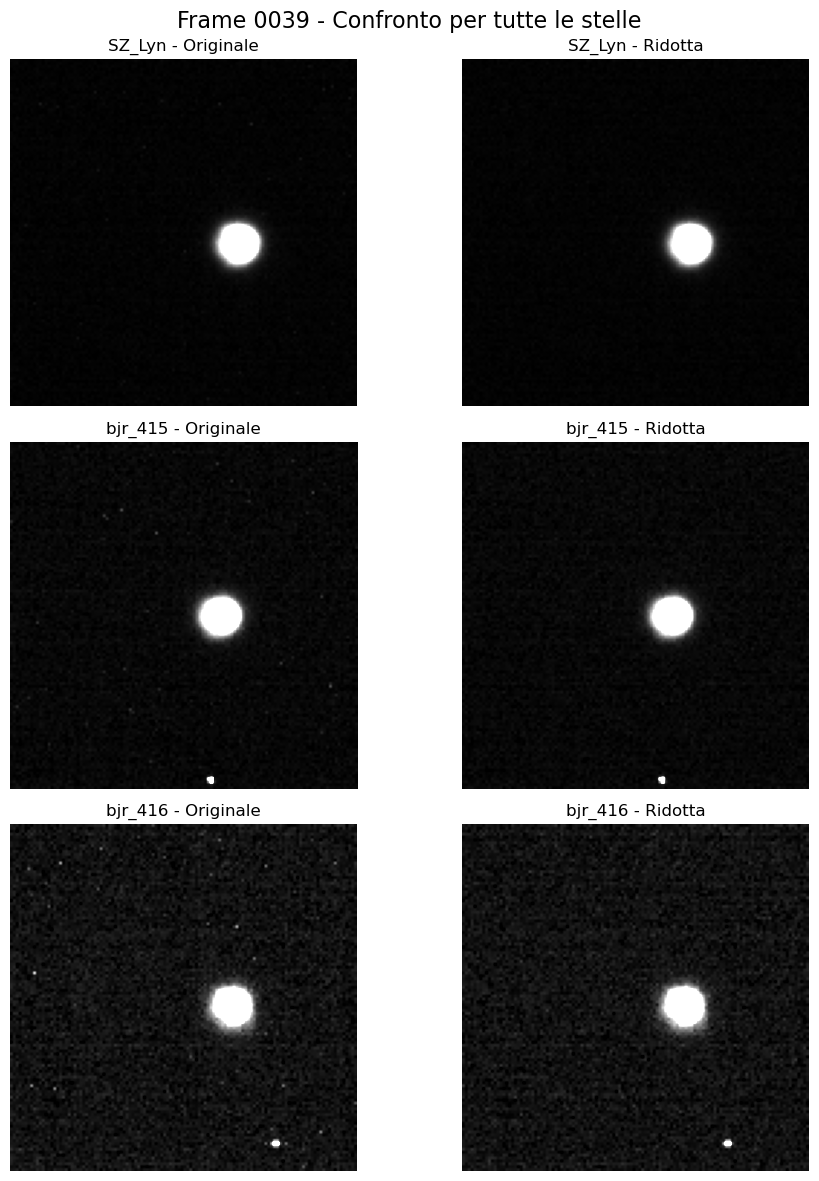

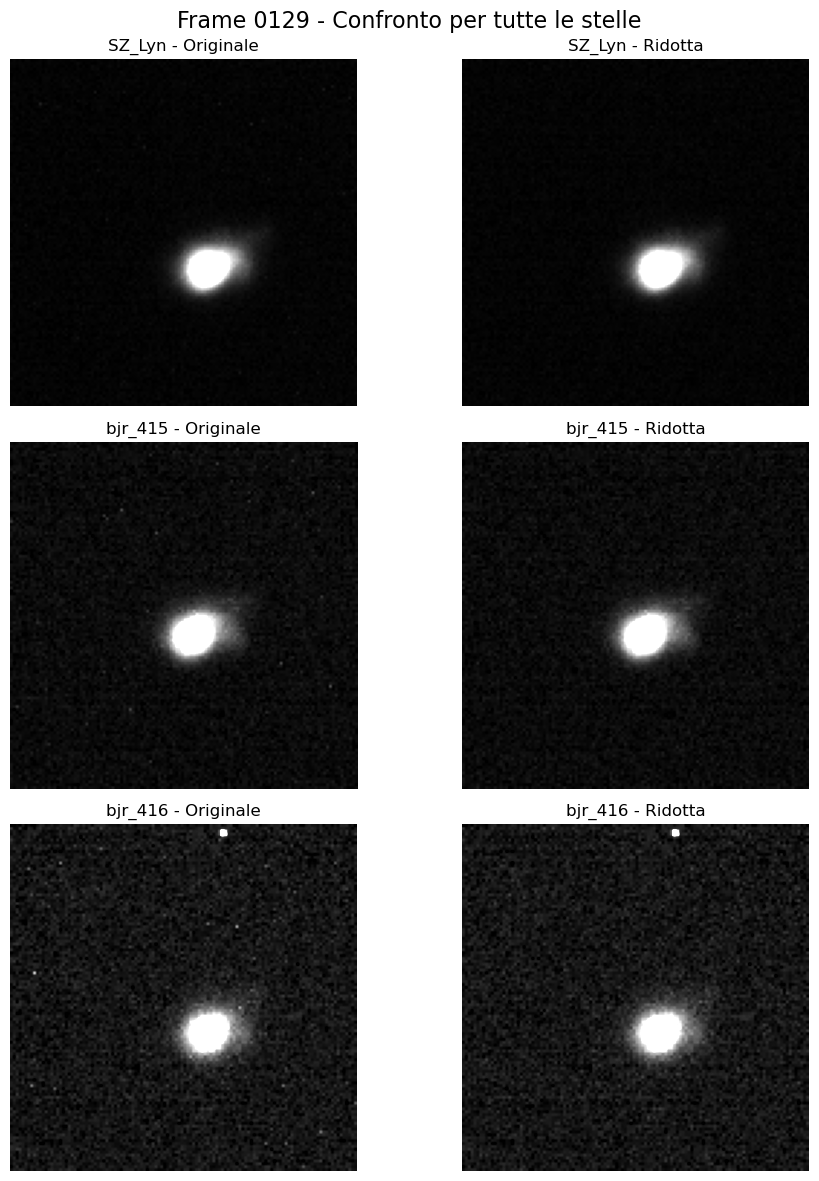

In [10]:
# --- ZOOM SU TUTTE E 3 LE STELLE PER I PRIMI 100 FRAME ---

from astropy.io import fits

# Dizionario con i range delle tre stelle
star_regions = {
    'SZ_Lyn':  ((550, 670), (800, 920)),
    'bjr_415': ((790, 910), (630, 750)),
    'bjr_416': ((480, 600), (550, 670))
}

# Cartelle con i file FITS
original_dir = '/Users/claudiamurro/Desktop/laboratorio tecnologie astronomiche/cupani/sci'
reduced_dir = '/Users/claudiamurro/Desktop/laboratorio tecnologie astronomiche/cupani/reduced'

# Funzione per caricare immagine FITS
def load_image(directory, filename):
    path = os.path.join(directory, filename)
    with fits.open(path) as hdul:
        return hdul[0].data.astype(np.float64)

# Lista di outlier
outlier_frames = [3, 9, 12, 20, 22, 23, 24, 33, 64, 66, 74, 81, 86, 87, 93, 95, 97]

# Loop su frame e stelle
for frame in [39,129]: #range(1, 101):
    original_name = f'SZ_Lyn-{frame:04d}_R.fit'
    reduced_name = f'SZ_Lyn-{frame:04d}_reduced.fit'
    
    try:
        fig, axes = plt.subplots(3, 2, figsize=(10, 12))
        fig.suptitle(f'Frame {frame:04d} - Confronto per tutte le stelle', fontsize=16)

        for i, (star, (x_range, y_range)) in enumerate(star_regions.items()):
            original = extract_subimage(load_image(original_dir, original_name), x_range, y_range)
            reduced = extract_subimage(load_image(reduced_dir, reduced_name), x_range, y_range)

            axes[i, 0].imshow(original, cmap='gray', origin='lower',
                              vmin=np.percentile(original, 5), vmax=np.percentile(original, 99))
            axes[i, 0].set_title(f'{star} - Originale')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(reduced, cmap='gray', origin='lower',
                              vmin=np.percentile(reduced, 5), vmax=np.percentile(reduced, 99))
            axes[i, 1].set_title(f'{star} - Ridotta')
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

        if frame in outlier_frames:
            print(f"Frame {frame:04d} è un outlier!")

    except FileNotFoundError as e:
        print(f"File mancante: {e}")


--- Curva di luce per SZ_Lyn ---

--- Curva di luce per bjr_415 ---

--- Curva di luce per bjr_416 ---


/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:60: RuntimeWarning: invalid value encountered in log10
  return 10.481 + 2.5 * np.log10(fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:62: RuntimeWarning: invalid value encountered in log10
  return 11.222 + 2.5 * np.log10(fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:64: RuntimeWarning: invalid value encountered in log10
  bjr_415_conv = 10.481 + 2.5 * np.log10(bjr_415_fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:65: RuntimeWarning: invalid value encountered in log10
  bjr_416_conv = 11.222 + 2.5 * np.log10(bjr_416_fluxes)
/var/folders/z9/_nl0zsn93mv5w448hcld4d540000gn/T/ipykernel_2290/2716454391.py:67: RuntimeWarning: invalid value encountered in log10
  return conv_mean - 2.5 * np.log10(fluxes)


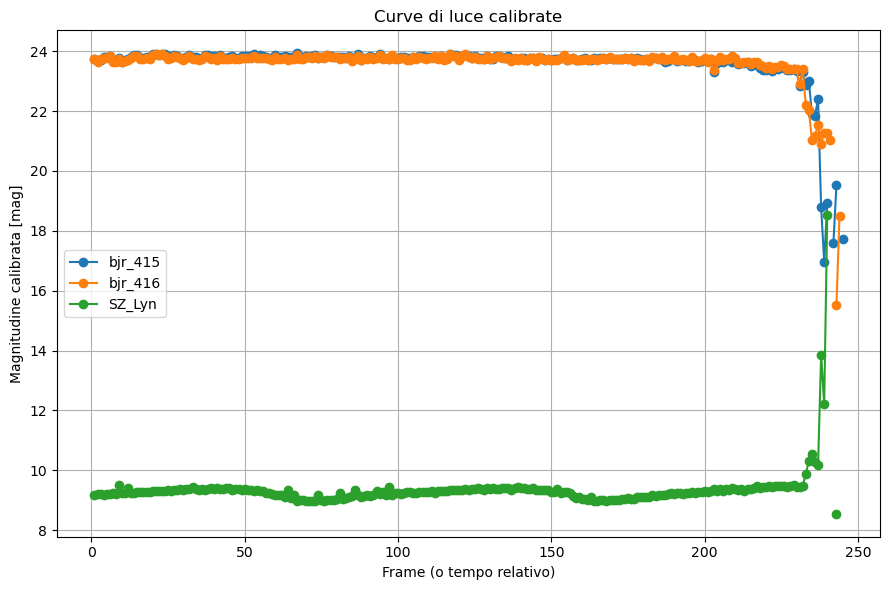

In [12]:
#MODIFICA!!!!!!
from scipy.ndimage import median_filter

def mask_cosmic_rays(image, threshold=5):
    """
    Maschera i raggi cosmici rilevati come outlier rispetto alla mediana locale.
    :param image: immagine da processare
    :param threshold: numero di sigma sopra cui un pixel è considerato outlier
    :return: immagine con i raggi cosmici mascherati
    """
    median = median_filter(image, size=10)
    diff = image - median
    std = np.std(diff)
    mask = diff > threshold * std
    image_cleaned = np.copy(image)
    image_cleaned[mask] = median[mask]  # sostituisce outlier con valore mediano
    return image_cleaned

def aperture_photometry(subimage, radius, gain=0.82, read_noise=10):
    subimage = mask_cosmic_rays(subimage)  # <--- maschera i raggi cosmici
    
    pos_max = np.unravel_index(np.nanargmax(subimage), subimage.shape)
    mask = create_circular_mask(subimage.shape, pos_max, radius)

    target = np.copy(subimage)
    bckg = np.copy(subimage)
    target[~mask] = np.nan
    bckg[mask] = np.nan

    target_flux = target * gain
    bckg_flux = bckg * gain

    # Background stimato con mediana robusta
    bckg_median = np.nanmedian(bckg_flux)
    object_flux = target_flux - bckg_median
    return np.nansum(object_flux)

# --- PLOT MULTIPLE CURVE DI LUCE ---

def plot_multiple_light_curves(data_dict):
    plt.figure(figsize=(9, 6))
    
    for star_name, (frames, fluxes) in data_dict.items():
        plt.plot(frames, fluxes, marker='o', linestyle='-', label=star_name)
    
    plt.xlabel("Frame (o tempo relativo)")
    plt.ylabel("Flusso integrato [e⁻]")
    plt.title("Curve di luce")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Funzione per calcolare e plottare le curve di luce calibrate
def plot_calibrated_light_curves(directory, prefix, suffix, star_regions, radius=15):
    results = {}
    raw_fluxes = {}

    for star_name, (x_range, y_range) in star_regions.items():
        print(f"\n--- Curva di luce per {star_name} ---")
        frames, fluxes = light_curve_from_series(directory, prefix, suffix,
                                                 x_range=x_range, y_range=y_range, radius=radius)
        raw_fluxes[star_name] = np.array(fluxes)

    # Calibrazione
    results['bjr_415'] = (frames, calibrate_fluxes(raw_fluxes['bjr_415'], 'bjr_415'))
    results['bjr_416'] = (frames, calibrate_fluxes(raw_fluxes['bjr_416'], 'bjr_416'))
    results['SZ_Lyn'] = (frames, calibrate_fluxes(raw_fluxes['SZ_Lyn'], 'SZ_Lyn',
                                                  bjr_415_fluxes=raw_fluxes['bjr_415'],
                                                  bjr_416_fluxes=raw_fluxes['bjr_416']))

    # Plotting
    plt.figure(figsize=(9, 6))
    for star_name, (frames, calibrated_fluxes) in results.items():
        plt.plot(frames, calibrated_fluxes, marker='o', linestyle='-', label=star_name)

    plt.xlabel("Frame (o tempo relativo)")
    #plt.xlim(0,100)
    #plt.ylim(23,25)
    plt.ylabel("Magnitudine calibrata [mag]")
    plt.title("Curve di luce calibrate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Esecuzione della funzione con la calibrazione
if __name__ == "__main__":
    base_dir = '/Users/claudiamurro/Desktop/laboratorio tecnologie astronomiche/cupani/reduced'
    file_prefix = 'SZ_Lyn-'

    star_regions = {
        'SZ_Lyn':  ((550, 670), (800, 920)),
        'bjr_415': ((790, 910), (630, 750)),   
      'bjr_416': ((480, 600), (550, 670))  
    }

    plot_calibrated_light_curves(base_dir, file_prefix, '_reduced.fit', star_regions, radius=15)

i frame sopra sono [9,12,64,66,74,81,86,93,95,97] e sono tutti quelli con una macchiolina sulla stella che quindi corrisponde a meno flusso letto (magnitudine maggiore)